# Online Model Analysis & Parameter Fine-Tuning

This notebook runs the **teacher-forced (online) Bayesian role-specialization model** on human data, evaluates fit via Pearson r and log-likelihood, and optionally fine-tunes τ and ε.

In [1]:
import csv
import importlib.util
import json
from collections import defaultdict
from itertools import product
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from memo import memo
from scipy.optimize import minimize
from scipy.stats import pearsonr

%matplotlib inline

## Configuration

In [2]:
# === Paths ===
SCRIPT_DIR = Path(".").resolve()
PROJECT_DIR = SCRIPT_DIR.parent
DEFAULT_DATA_DIR = PROJECT_DIR / "bayesian-role-specialization-2026-02-13-10-37-44"
VALUE_MATRICES_DIR = PROJECT_DIR / "human_envs_value_matrices"
ENVS_DIR = PROJECT_DIR / "envs"
OUTPUT_DIR = SCRIPT_DIR / "figures" / "model_comparison_online_old_pilot"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Role combo → numeric env ID from envs/
ROLE_COMBO_TO_ENV_NUM = {
    "FFF": 82, "FFM": 5189, "FMM": 2712, "FTF": 157,
    "FTM": 139, "MFF": 957, "MMM": 4915, "TFF": 855,
}

# === Constants ===
F, T, M = 0, 1, 2
ATTACK, DEFEND, HEAL = 0, 1, 2
ROLE_NAMES = {0: "F", 1: "T", 2: "M"}
ROLE_CHAR_TO_IDX = {"F": 0, "T": 1, "M": 2}
GAME_ROLE_TO_IDX = {"FIGHTER": 0, "TANK": 1, "MEDIC": 2}
EPSILON = 1e-10
MAX_STAGES = 5
TURNS_PER_STAGE = 2
TAU = 1.0
DROPOUT_GAME_ID = "01KK14SSY8E64SK69715NN1TMW"
ROLE_STAT_COL = {0: 0, 1: 1, 2: 2}
ROLE_COLORS = {"F": "#e74c3c", "T": "#3498db", "M": "#2ecc71"}

ALL_ROLE_COMBOS = [
    ROLE_NAMES[r0] + ROLE_NAMES[r1] + ROLE_NAMES[r2]
    for r0 in range(3) for r1 in range(3) for r2 in range(3)
]

SYMMETRIC_PROFILES = {
    "222_222_222": "all",
    "411_222_222": "last_two",
    "114_222_222": "last_two",
    "141_222_222": "last_two",
}

# Data directories - OLD PILOT DATA
data_dirs = [str(DEFAULT_DATA_DIR)]

print(f"Data dirs: {data_dirs}")

Data dirs: ['/Users/bhavyesh/Desktop/bayesian-role-specialization/computational_model/bayesian-role-specialization-2026-02-13-10-37-44']


## Helper Functions

In [3]:
def canonical_combo(combo, stat_profile):
    sym = SYMMETRIC_PROFILES.get(stat_profile)
    if sym == "all":
        return "".join(sorted(combo))
    elif sym == "last_two":
        return combo[0] + "".join(sorted(combo[1:]))
    return combo


def get_canonical_combos(stat_profile):
    seen = set()
    canonical = []
    for c in ALL_ROLE_COMBOS:
        cc = canonical_combo(c, stat_profile)
        if cc not in seen:
            seen.add(cc)
            canonical.append(cc)
    return canonical

## Core Model

In [4]:
def utility_based_prior(player_stats, tau=1.0):
    """P(r0,r1,r2) ∝ exp(Σ_i stat_i(r_i) / τ)"""
    prior = np.zeros((3, 3, 3))
    for r0 in range(3):
        for r1 in range(3):
            for r2 in range(3):
                utility = (
                    float(player_stats[0, ROLE_STAT_COL[r0]])
                    + float(player_stats[1, ROLE_STAT_COL[r1]])
                    + float(player_stats[2, ROLE_STAT_COL[r2]])
                )
                prior[r0, r1, r2] = utility / tau
    prior -= prior.max()
    prior = np.exp(prior)
    prior /= prior.sum()
    return prior


def uniform_prior():
    """Flat 1/27 prior over all role combinations."""
    return np.ones((3, 3, 3)) / 27.0


def _preferred_action(role, intent, team_hp, team_max_hp):
    if role == F:
        return ATTACK
    elif role == T:
        return DEFEND if intent == 1 else ATTACK
    else:
        return HEAL if team_hp < team_max_hp else ATTACK


# --- Memo-based Bayesian inference (from simulation/inference.py) ---

ROLES = [0, 1, 2]
ACTIONS = [0, 1, 2]


@jax.jit
def _get_element(array, i0, i1, i2):
    return array[i0, i1, i2]


def _role_policy(role, action, intent, team_hp, team_max_hp, epsilon):
    """P(action | role, state). Parameterized version of pi.choose_policy."""
    fighter = jnp.where(action == ATTACK, 1.0 - epsilon, epsilon / 2.0)
    tank_pref = jnp.where(intent == 1, DEFEND, ATTACK)
    tank = jnp.where(action == tank_pref, 1.0 - epsilon, epsilon / 2.0)
    medic_pref = jnp.where(team_hp < team_max_hp, HEAL, ATTACK)
    medic = jnp.where(action == medic_pref, 1.0 - epsilon, epsilon / 2.0)
    return jnp.where(role == F, fighter, jnp.where(role == T, tank, medic))


@memo
def role_inference[r0: ROLES, r1: ROLES, r2: ROLES](
    role_prior: ..., obs_a0, obs_a1, obs_a2, intent, team_hp, team_max_hp, epsilon
):
    """Infers P(roles | observations) using memo-lang Bayesian inference."""
    observer: knows(r0, r1, r2)
    observer: thinks[
        team: assigned(r0 in ROLES, r1 in ROLES, r2 in ROLES,
                       wpp=_get_element(role_prior, r0, r1, r2)),
        team: chooses(a0 in ACTIONS, wpp=_role_policy(r0, a0, intent, team_hp, team_max_hp, epsilon)),
        team: chooses(a1 in ACTIONS, wpp=_role_policy(r1, a1, intent, team_hp, team_max_hp, epsilon)),
        team: chooses(a2 in ACTIONS, wpp=_role_policy(r2, a2, intent, team_hp, team_max_hp, epsilon))
    ]
    observer: observes_that[team.a0 == obs_a0]
    observer: observes_that[team.a1 == obs_a1]
    observer: observes_that[team.a2 == obs_a2]
    return observer[Pr[r0 == team.r0 and r1 == team.r1 and r2 == team.r2]]


def bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon=EPSILON):
    posterior = np.array(role_inference(
        jnp.array(prior), actions[0], actions[1], actions[2],
        intent, team_hp, team_max_hp, epsilon
    ))
    total = posterior.sum()
    if total > 0:
        posterior /= total
    else:
        posterior = np.ones((3, 3, 3)) / 27.0
    return posterior


def softmax_role_dist(agent_i, intent, team_hp, enemy_hp, prior, values, tau=1.0):
    other_agents = [a for a in range(3) if a != agent_i]
    other_probs = np.sum(prior, axis=agent_i)
    total = other_probs.sum()
    other_probs = other_probs / total if total > 0 else np.ones((3, 3)) / 9.0

    expected_values = np.zeros(3)
    for r_i in range(3):
        ev = 0.0
        for r_j in range(3):
            for r_k in range(3):
                roles = [0, 0, 0]
                roles[agent_i] = r_i
                roles[other_agents[0]] = r_j
                roles[other_agents[1]] = r_k
                flat_idx = roles[0] * 9 + roles[1] * 3 + roles[2]
                ev += other_probs[r_j, r_k] * float(values[flat_idx, intent, team_hp, enemy_hp])
        expected_values[r_i] = ev

    ev_scaled = expected_values / tau
    ev_scaled -= ev_scaled.max()
    exp_ev = np.exp(ev_scaled)
    return exp_ev / exp_ev.sum()


def game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp):
    total_attack = sum(float(player_stats[i, 0]) for i in range(3) if actions[i] == ATTACK)
    defenders = [float(player_stats[i, 1]) for i in range(3) if actions[i] == DEFEND]
    max_defense = max(defenders) if defenders else 0.0
    total_heal = sum(float(player_stats[i, 2]) for i in range(3) if actions[i] == HEAL)

    new_enemy_hp = max(0.0, enemy_hp - total_attack)
    damage = max(0.0, boss_damage - max_defense) if intent == 1 else 0.0
    new_team_hp = max(0.0, min(float(team_max_hp), team_hp - damage + total_heal))
    return new_team_hp, new_enemy_hp

## Data Loading

In [5]:
def load_config_module(config_path):
    spec = importlib.util.spec_from_file_location(f"config_{hash(str(config_path))}", config_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


def load_team_rounds(data_dirs):
    dirs = [Path(d) for d in data_dirs]

    games = {}
    rounds = []
    for d in dirs:
        with open(d / "game.csv") as f:
            games.update({r["id"]: r for r in csv.DictReader(f)})
    for d in dirs:
        with open(d / "round.csv") as f:
            rounds.extend(csv.DictReader(f))

    env_cache = {}
    records = []
    skipped_none = 0

    for r in rounds:
        game = games.get(r["gameID"])
        if not game or game.get("status") != "ended":
            continue

        rnum = r["roundNumber"]
        cfg_key = f"round{rnum}Config"
        if not game.get(cfg_key):
            continue

        cfg = json.loads(game[cfg_key])
        if cfg.get("botPlayers"):
            continue

        env_id = cfg["envId"]
        optimal_roles = cfg["optimalRoles"]
        role_combo = "".join(ROLE_NAMES[ri] for ri in optimal_roles)
        stat_profile = cfg.get("statProfileId", "")
        lds = [int(c) for c in cfg["enemyIntentSequence"]]

        if env_id not in env_cache:
            val_dir = VALUE_MATRICES_DIR / role_combo
            if not (val_dir / "values.npy").exists():
                val_dir = ENVS_DIR / str(env_id)
            values = np.load(val_dir / "values.npy")
            config_mod = load_config_module(val_dir / "config.py")
            env_cache[env_id] = {
                "values": values,
                "player_stats": np.array(config_mod.PLAYER_STATS, dtype=float),
                "boss_damage": float(config_mod.BOSS_DAMAGE),
                "team_max_hp": int(config_mod.TEAM_MAX_HP),
                "enemy_max_hp": int(config_mod.ENEMY_MAX_HP),
            }

        stage_roles = []
        has_none = False
        for s in range(1, MAX_STAGES + 1):
            turns_data = r.get(f"stage{s}Turns")
            if not turns_data:
                break
            turns = json.loads(turns_data)
            if not turns:
                break
            roles = turns[0].get("roles", [])
            if len(roles) != 3:
                break
            if None in roles:
                has_none = True
                break
            combo_str = "".join(ROLE_NAMES[GAME_ROLE_TO_IDX.get(rs, 0)] for rs in roles)
            stage_roles.append(combo_str)

        if has_none:
            skipped_none += 1
            continue

        if not stage_roles:
            continue

        records.append({
            "game_id": r["gameID"],
            "round_id": r["id"],
            "env_id": env_id,
            "stat_profile": stat_profile,
            "optimal_roles": role_combo,
            "lds": lds,
            "stage_roles": stage_roles,
            "env_config": env_cache[env_id],
        })

    print(f"Skipped {skipped_none} rounds with dropout (None roles)")
    return records

## Teacher-Forced Prediction & Aggregation

In [6]:
def combo_marginal(combo):
    """Role frequencies from a combo string. 'FTM' -> [1/3, 1/3, 1/3]."""
    counts = np.zeros(3)
    for c in combo:
        counts[ROLE_CHAR_TO_IDX[c]] += 1
    return counts / 3.0


def teacher_forced_predictions(record, tau=TAU, prior_type="utility", epsilon=EPSILON):
    env = record["env_config"]
    values, player_stats = env["values"], env["player_stats"]
    boss_damage = env["boss_damage"]
    team_max_hp, enemy_max_hp = env["team_max_hp"], env["enemy_max_hp"]

    team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
    if prior_type == "uniform":
        prior = uniform_prior()
    else:
        prior = utility_based_prior(player_stats, tau=tau)
    results = []
    turn_idx = 0

    for human_combo in record["stage_roles"]:
        if turn_idx >= len(record["lds"]) or team_hp <= 0 or enemy_hp <= 0:
            break

        intent = record["lds"][turn_idx]
        thp = int(min(max(0, team_hp), team_max_hp))
        ehp = int(min(max(0, enemy_hp), enemy_max_hp))

        per_agent = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau) for i in range(3)]

        predicted_dist = {}
        for r0 in range(3):
            for r1 in range(3):
                for r2 in range(3):
                    combo = ROLE_NAMES[r0] + ROLE_NAMES[r1] + ROLE_NAMES[r2]
                    predicted_dist[combo] = float(per_agent[0][r0] * per_agent[1][r1] * per_agent[2][r2])

        results.append({
            "predicted_dist": predicted_dist,
            "human_combo": human_combo,
            "model_marginal": np.mean(per_agent, axis=0),
        })

        human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
        for _ in range(TURNS_PER_STAGE):
            if turn_idx >= len(record["lds"]) or team_hp <= 0 or enemy_hp <= 0:
                break
            intent = record["lds"][turn_idx]
            actions = [_preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
            prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
            team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
            turn_idx += 1

    return results


def run_all_predictions(records, tau=TAU, prior_type="utility", epsilon=EPSILON):
    by_env = defaultdict(list)
    for rec in records:
        by_env[rec["env_id"]].append(rec)

    all_results = {}

    for env_id, env_records in by_env.items():
        stat_profile = env_records[0]["stat_profile"]
        optimal = env_records[0]["optimal_roles"]
        canon_combos = get_canonical_combos(stat_profile)

        stage_predicted = defaultdict(lambda: defaultdict(float))
        stage_human = defaultdict(lambda: defaultdict(int))
        stage_model_marg = defaultdict(lambda: np.zeros(3))
        stage_human_marg = defaultdict(lambda: np.zeros(3))
        stage_counts = defaultdict(int)
        team_predictions = []
        max_stages = 0

        for rec in env_records:
            preds = teacher_forced_predictions(rec, tau=tau, prior_type=prior_type, epsilon=epsilon)
            team_predictions.append(preds)

            for s, pred in enumerate(preds):
                stage_counts[s] += 1
                max_stages = max(max_stages, s + 1)

                for combo, prob in pred["predicted_dist"].items():
                    stage_predicted[s][canonical_combo(combo, stat_profile)] += prob
                stage_human[s][canonical_combo(pred["human_combo"], stat_profile)] += 1

                stage_model_marg[s] += pred["model_marginal"]
                stage_human_marg[s] += combo_marginal(pred["human_combo"])

        predicted_avg, model_marg_avg, human_marg_avg = {}, {}, {}
        for s in range(max_stages):
            n = stage_counts[s]
            if n > 0:
                predicted_avg[s] = {cc: stage_predicted[s].get(cc, 0.0) / n for cc in canon_combos}
                model_marg_avg[s] = stage_model_marg[s] / n
                human_marg_avg[s] = stage_human_marg[s] / n

        all_results[env_id] = {
            "stat_profile": stat_profile,
            "optimal": optimal,
            "canonical_optimal": canonical_combo(optimal, stat_profile),
            "canonical_combos": canon_combos,
            "n_teams": len(env_records),
            "max_stages": max_stages,
            "stage_predicted": predicted_avg,
            "stage_human": dict(stage_human),
            "stage_counts": dict(stage_counts),
            "team_predictions": team_predictions,
            "stage_model_marginal": model_marg_avg,
            "stage_human_marginal": human_marg_avg,
        }

    return all_results

## Evaluation Metrics

In [7]:
def compute_pearson(all_results):
    correlations = {}
    global_combo_m, global_combo_h = [], []
    global_marg_m, global_marg_h = [], []

    for env_id, data in all_results.items():
        combo_m, combo_h, marg_m, marg_h = [], [], [], []

        for s in range(data["max_stages"]):
            predicted = data["stage_predicted"].get(s)
            human_counts = data["stage_human"].get(s, {})
            n = data["stage_counts"].get(s, 0)
            if predicted is None or n == 0:
                continue

            for cc in data["canonical_combos"]:
                combo_m.append(predicted.get(cc, 0.0))
                combo_h.append(human_counts.get(cc, 0) / n)

            mm = data["stage_model_marginal"].get(s)
            hm = data["stage_human_marginal"].get(s)
            if mm is not None and hm is not None:
                marg_m.extend(mm.tolist())
                marg_h.extend(hm.tolist())

        env_corr = {}
        if len(combo_m) >= 2:
            r, p = pearsonr(combo_m, combo_h)
            env_corr["combo"] = {"r": float(r), "p": float(p), "n": len(combo_m)}
        if len(marg_m) >= 2:
            r, p = pearsonr(marg_m, marg_h)
            env_corr["marginal"] = {"r": float(r), "p": float(p), "n": len(marg_m)}

        correlations[env_id] = env_corr
        global_combo_m.extend(combo_m)
        global_combo_h.extend(combo_h)
        global_marg_m.extend(marg_m)
        global_marg_h.extend(marg_h)

    global_corr = {}
    if len(global_combo_m) >= 2:
        r, p = pearsonr(global_combo_m, global_combo_h)
        global_corr["combo"] = {"r": float(r), "p": float(p), "n": len(global_combo_m)}
    if len(global_marg_m) >= 2:
        r, p = pearsonr(global_marg_m, global_marg_h)
        global_corr["marginal"] = {"r": float(r), "p": float(p), "n": len(global_marg_m)}
    correlations["__global__"] = global_corr

    return correlations


def compute_log_likelihood(all_results):
    ll_by_env = {}
    for env_id, data in all_results.items():
        log_liks = []
        for team_preds in data["team_predictions"]:
            for pred in team_preds:
                prob = pred["predicted_dist"].get(pred["human_combo"], 1e-20)
                log_liks.append(np.log(max(prob, 1e-20)))
        if log_liks:
            ll_by_env[env_id] = {"mean_ll": float(np.mean(log_liks)), "n": len(log_liks)}
    return ll_by_env

## Plotting

In [8]:
def plot_comparison(all_results, correlations, tau=TAU, epsilon=EPSILON, save=False):
    for env_id, data in all_results.items():
        canon_combos = data["canonical_combos"]
        optimal_canon = data["canonical_optimal"]
        max_stages = data["max_stages"]
        stages = list(range(1, max_stages + 1))

        model_probs = {cc: [] for cc in canon_combos}
        human_probs = {cc: [] for cc in canon_combos}
        for s in range(max_stages):
            predicted = data["stage_predicted"].get(s, {})
            human_counts = data["stage_human"].get(s, {})
            n = data["stage_counts"].get(s, 0)
            for cc in canon_combos:
                model_probs[cc].append(predicted.get(cc, 0.0))
                human_probs[cc].append(human_counts.get(cc, 0) / n if n > 0 else 0)

        played = [
            cc for cc in canon_combos
            if cc == optimal_canon
            or any(p > 0 for p in human_probs[cc])
            or any(p > 0.02 for p in model_probs[cc])
        ]

        fig, axes = plt.subplots(1, 3, figsize=(20, 5))

        for cc in played:
            is_opt = cc == optimal_canon
            kw = dict(linewidth=2.5 if is_opt else 1.2, markersize=8 if is_opt else 4,
                       label=f"{cc} (optimal)" if is_opt else cc)
            if is_opt:
                kw["color"] = "red"
            axes[0].plot(stages, human_probs[cc], "o-", **kw)
            axes[1].plot(stages, model_probs[cc], "o-", **kw)

        for role_idx, role_name in ROLE_NAMES.items():
            h_vals = [data["stage_human_marginal"].get(s, np.zeros(3))[role_idx] for s in range(max_stages)]
            m_vals = [data["stage_model_marginal"].get(s, np.zeros(3))[role_idx] for s in range(max_stages)]
            color = ROLE_COLORS[role_name]
            axes[2].plot(stages, h_vals, "o-", color=color, linewidth=2, label=f"{role_name} human")
            axes[2].plot(stages, m_vals, "s--", color=color, linewidth=2, alpha=0.7, label=f"{role_name} model")

        env_corr = correlations.get(env_id, {})
        combo_r = env_corr.get("combo", {}).get("r", float("nan"))
        marg_r = env_corr.get("marginal", {}).get("r", float("nan"))

        for ax, title in [(axes[0], f"Human ({data['n_teams']} teams)"),
                          (axes[1], f"Model (τ={tau}, ε={epsilon:.4g})")]:
            ax.set_xlabel("Stage")
            ax.set_ylabel("P(combo)")
            ax.set_title(title)
            ax.set_xticks(stages)
            ax.set_ylim(-0.05, 1.05)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

        axes[2].set_xlabel("Stage")
        axes[2].set_ylabel("P(role)")
        axes[2].set_title(f"Marginals (r={marg_r:.3f})" if not np.isnan(marg_r) else "Marginals")
        axes[2].set_xticks(stages)
        axes[2].set_ylim(-0.05, 1.05)
        axes[2].legend(fontsize=7)
        axes[2].grid(True, alpha=0.3)

        r_str = f"combo r={combo_r:.3f}" if not np.isnan(combo_r) else "combo r=N/A"
        fig.suptitle(
            f"{env_id} | {data['stat_profile']} | Optimal: {optimal_canon} | {r_str}",
            fontsize=12, fontweight="bold",
        )
        plt.tight_layout()

        if save:
            role_combo = data["optimal"]
            env_num = ROLE_COMBO_TO_ENV_NUM.get(role_combo, "")
            folder_name = f"{env_num}_{env_id}" if env_num else env_id
            env_dir = OUTPUT_DIR / folder_name
            env_dir.mkdir(parents=True, exist_ok=True)
            fig.savefig(env_dir / f"online_{env_id}.png", dpi=150, bbox_inches="tight")

        plt.show()

        # Bar chart
        n_stages = max_stages
        fig_bar, axes_bar = plt.subplots(1, n_stages, figsize=(5 * n_stages, 5), sharey=True)
        if n_stages == 1:
            axes_bar = [axes_bar]

        bar_width = 0.35
        for s in range(n_stages):
            ax = axes_bar[s]
            h_vals = [human_probs[cc][s] for cc in played]
            m_vals = [model_probs[cc][s] for cc in played]
            x = np.arange(len(played))

            ax.bar(x - bar_width / 2, h_vals, bar_width, label="Human", color="#3498db", alpha=0.8)
            ax.bar(x + bar_width / 2, m_vals, bar_width, label="Model", color="#e74c3c", alpha=0.8)

            for i, cc in enumerate(played):
                if cc == optimal_canon:
                    ax.bar(x[i] - bar_width / 2, h_vals[i], bar_width, color="#3498db", edgecolor="gold", linewidth=2.5)
                    ax.bar(x[i] + bar_width / 2, m_vals[i], bar_width, color="#e74c3c", edgecolor="gold", linewidth=2.5)

            ax.set_xlabel("Role combo")
            ax.set_title(f"Stage {s + 1}")
            ax.set_xticks(x)
            ax.set_xticklabels([f"{cc}*" if cc == optimal_canon else cc for cc in played],
                               rotation=45, ha="right", fontsize=7)
            ax.set_ylim(0, 1.05)
            ax.grid(True, alpha=0.3, axis="y")
            if s == 0:
                ax.set_ylabel("P(combo)")
                ax.legend(fontsize=8)

        r_str = f"combo r={combo_r:.3f}" if not np.isnan(combo_r) else "combo r=N/A"
        fig_bar.suptitle(
            f"{env_id} | {data['stat_profile']} | Optimal: {optimal_canon}* | {r_str} | τ={tau}, ε={epsilon:.4g}",
            fontsize=12, fontweight="bold",
        )
        plt.tight_layout()

        if save:
            fig_bar.savefig(env_dir / f"online_{env_id}_bars.png", dpi=150, bbox_inches="tight")

        plt.show()

## 1. Load Data

In [9]:
records = load_team_rounds(data_dirs=data_dirs)
n_envs = len(set(r["env_id"] for r in records))
print(f"Loaded {len(records)} team-rounds across {n_envs} envs")

Metal device set to: Apple M4

systemMemory: 16.00 GB
maxCacheSize: 5.92 GB

Skipped 8 rounds with dropout (None roles)
Loaded 22 team-rounds across 6 envs


W0000 00:00:1773696318.718909   93582 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1773696318.729577   93582 service.cc:145] XLA service 0xaa1941b00 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773696318.729585   93582 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1773696318.730635   93582 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1773696318.730643   93582 mps_client.cc:384] XLA backend will use up to 12712640512 bytes on device 0 for SimpleAllocator.


## 2. Fine-Tune τ and ε

Coarse 2D grid search → refinement → scipy polishing.

In [10]:
# Fine-tuning settings
prior_type = "utility"   # "utility" or "uniform"
metric = "combo_r"       # optimize combo Pearson r
tau_min, tau_max, tau_steps = 0.1, 10.0, 50
eps_min, eps_max, eps_steps = 0.001, 0.2, 20

In [11]:
def evaluate(records, tau, prior_type="utility", epsilon=EPSILON):
    """Run model at given (τ, ε) and return fit metrics."""
    results = run_all_predictions(records, tau=tau, prior_type=prior_type, epsilon=epsilon)
    correlations = compute_pearson(results)
    ll = compute_log_likelihood(results)

    g = correlations.get("__global__", {})
    combo_r = g.get("combo", {}).get("r", float("nan"))
    marg_r = g.get("marginal", {}).get("r", float("nan"))
    mean_ll = float(np.mean([v["mean_ll"] for v in ll.values()])) if ll else float("nan")

    return {
        "tau": tau,
        "epsilon": epsilon,
        "combo_r": combo_r,
        "marg_r": marg_r,
        "mean_ll": mean_ll,
        "correlations": correlations,
        "log_likelihood": ll,
    }


def grid_search_2d(records, tau_values, epsilon_values, prior_type="utility"):
    results = []
    total = len(tau_values) * len(epsilon_values)
    for i, (t, eps) in enumerate(product(tau_values, epsilon_values), 1):
        if i % 50 == 0 or i == total:
            print(f"  [{i}/{total}] ...", flush=True)
        res = evaluate(records, t, prior_type=prior_type, epsilon=eps)
        results.append(res)
    return results


def pick_best(results, metric="ll"):
    if metric == "ll":
        return max(results, key=lambda r: r["mean_ll"] if not np.isnan(r["mean_ll"]) else -np.inf)
    return max(results, key=lambda r: r["combo_r"] if not np.isnan(r["combo_r"]) else -np.inf)

In [12]:
# Step 1: Coarse grid search
tau_values = np.linspace(tau_min, tau_max, tau_steps)
eps_values = np.geomspace(eps_min, eps_max, eps_steps)
print(f"Coarse grid: {tau_steps} τ x {eps_steps} ε = {tau_steps * eps_steps} points")
print(f"  τ in [{tau_min}, {tau_max}], ε in [{eps_min}, {eps_max}]")
print(f"  prior = {prior_type}\n")

sweep_results = grid_search_2d(records, tau_values, eps_values, prior_type=prior_type)
best_result = pick_best(sweep_results, metric)
print(f"\nCoarse best: τ={best_result['tau']:.4f} ε={best_result['epsilon']:.6f} "
      f"combo_r={best_result['combo_r']:.4f} mean_LL={best_result['mean_ll']:.4f}")

Coarse grid: 50 τ x 20 ε = 1000 points
  τ in [0.1, 10.0], ε in [0.001, 0.2]
  prior = utility



  [50/1000] ...
  [100/1000] ...
  [150/1000] ...
  [200/1000] ...
  [250/1000] ...
  [300/1000] ...
  [350/1000] ...
  [400/1000] ...
  [450/1000] ...
  [500/1000] ...
  [550/1000] ...
  [600/1000] ...
  [650/1000] ...
  [700/1000] ...
  [750/1000] ...
  [800/1000] ...
  [850/1000] ...
  [900/1000] ...
  [950/1000] ...
  [1000/1000] ...

Coarse best: τ=10.0000 ε=0.065555 combo_r=0.1834 mean_LL=-4.1811


In [13]:
# Step 2: Refine around best
tau_step = (tau_max - tau_min) / tau_steps
eps_ratio = (eps_max / eps_min) ** (1.0 / eps_steps)

fine_taus = np.linspace(
    max(tau_min, best_result["tau"] - tau_step),
    min(tau_max, best_result["tau"] + tau_step),
    20,
)
fine_eps = np.geomspace(
    max(eps_min, best_result["epsilon"] / eps_ratio),
    min(eps_max, best_result["epsilon"] * eps_ratio),
    20,
)
print(f"Refining around τ={best_result['tau']:.4f} ε={best_result['epsilon']:.4f} ...")
refined = grid_search_2d(records, fine_taus, fine_eps, prior_type=prior_type)
sweep_results.extend(refined)
best_result = pick_best(sweep_results, metric)
print(f"\nRefined best: τ={best_result['tau']:.4f} ε={best_result['epsilon']:.6f} "
      f"combo_r={best_result['combo_r']:.4f} mean_LL={best_result['mean_ll']:.4f}")

Refining around τ=10.0000 ε=0.0656 ...
  [50/400] ...
  [100/400] ...
  [150/400] ...
  [200/400] ...
  [250/400] ...
  [300/400] ...
  [350/400] ...
  [400/400] ...

Refined best: τ=10.0000 ε=0.059459 combo_r=0.1834 mean_LL=-4.1879


In [14]:
# Step 3: Scipy polishing
tau_lo = max(tau_min, best_result["tau"] - tau_step / 2)
tau_hi = min(tau_max, best_result["tau"] + tau_step / 2)
eps_lo = max(1e-6, best_result["epsilon"] / 2)
eps_hi = min(eps_max, best_result["epsilon"] * 2)

def objective(params):
    t, eps = params
    res = evaluate(records, t, prior_type=prior_type, epsilon=eps)
    return -res["mean_ll"] if metric == "ll" else -res["combo_r"]

x0 = [(tau_lo + tau_hi) / 2, (eps_lo + eps_hi) / 2]
bounds = [(tau_lo, tau_hi), (eps_lo, eps_hi)]

print(f"Scipy optimization (metric={metric}) ...")
print(f"  bounds: τ in [{tau_lo:.4f}, {tau_hi:.4f}], ε in [{eps_lo:.6f}, {eps_hi:.6f}]")
opt_result = minimize(objective, x0, method="L-BFGS-B", bounds=bounds,
                      options={"maxiter": 50, "ftol": 1e-6})
opt_tau, opt_eps = opt_result.x
print(f"  Optimal τ={opt_tau:.4f} ε={opt_eps:.6f}  (objective={-opt_result.fun:.4f})")

opt_eval = evaluate(records, opt_tau, prior_type=prior_type, epsilon=opt_eps)
sweep_results.append(opt_eval)
best_result = pick_best(sweep_results, metric)

Scipy optimization (metric=combo_r) ...
  bounds: τ in [9.9010, 10.0000], ε in [0.029729, 0.118917]
  Optimal τ=9.9541 ε=0.051709  (objective=0.1831)


## 3. Results Summary

In [15]:
# Baseline comparison
baseline = evaluate(records, 1.0, prior_type=prior_type)

print(f"{'='*60}")
print(f"Prior: {prior_type}")
print(f"BEST τ = {best_result['tau']:.4f}, ε = {best_result['epsilon']:.6f}")
print(f"  combo_r  = {best_result['combo_r']:.4f}")
print(f"  marg_r   = {best_result['marg_r']:.4f}")
print(f"  mean_LL  = {best_result['mean_ll']:.4f}")
print(f"{'='*60}")
print(f"\nComparison with defaults (τ=1.0, ε=1e-10):")
print(f"  {'metric':<10} {'default':>10} {'best':>10} {'delta':>10}")
print(f"  {'combo_r':<10} {baseline['combo_r']:>10.4f} {best_result['combo_r']:>10.4f} {best_result['combo_r'] - baseline['combo_r']:>+10.4f}")
print(f"  {'marg_r':<10} {baseline['marg_r']:>10.4f} {best_result['marg_r']:>10.4f} {best_result['marg_r'] - baseline['marg_r']:>+10.4f}")
print(f"  {'mean_LL':<10} {baseline['mean_ll']:>10.4f} {best_result['mean_ll']:>10.4f} {best_result['mean_ll'] - baseline['mean_ll']:>+10.4f}")

# Per-environment correlations
print(f"\nPer-environment correlations at best (τ={best_result['tau']:.4f}, ε={best_result['epsilon']:.6f}):")
best_corrs = best_result["correlations"]
for env_id in sorted(k for k in best_corrs if k != "__global__"):
    c = best_corrs[env_id]
    combo = c.get("combo", {})
    marg = c.get("marginal", {})
    parts = []
    if combo:
        parts.append(f"combo_r={combo['r']:.4f}")
    if marg:
        parts.append(f"marg_r={marg['r']:.4f}")
    print(f"  {env_id}: {', '.join(parts)}")
g = best_corrs.get("__global__", {})
if g:
    print(f"  GLOBAL: combo_r={g.get('combo', {}).get('r', float('nan')):.4f}, "
          f"marg_r={g.get('marginal', {}).get('r', float('nan')):.4f}")

Prior: utility
BEST τ = 10.0000, ε = 0.059459
  combo_r  = 0.1834
  marg_r   = 0.0840
  mean_LL  = -4.1879

Comparison with defaults (τ=1.0, ε=1e-10):
  metric        default       best      delta
  combo_r        0.0409     0.1834    +0.1425
  marg_r         0.0752     0.0840    +0.0087
  mean_LL      -29.6374    -4.1879   +25.4495

Per-environment correlations at best (τ=10.0000, ε=0.059459):
  2209: combo_r=-0.0268, marg_r=0.9959
  2319: combo_r=0.2600, marg_r=0.0954
  4060: combo_r=0.3762, marg_r=0.1940
  4119: combo_r=-0.1837, marg_r=0.0901
  6949: combo_r=-0.2811, marg_r=0.0795
  959: combo_r=0.1075, marg_r=0.0252
  GLOBAL: combo_r=0.1834, marg_r=0.0840


## 4. Plots with Best Parameters

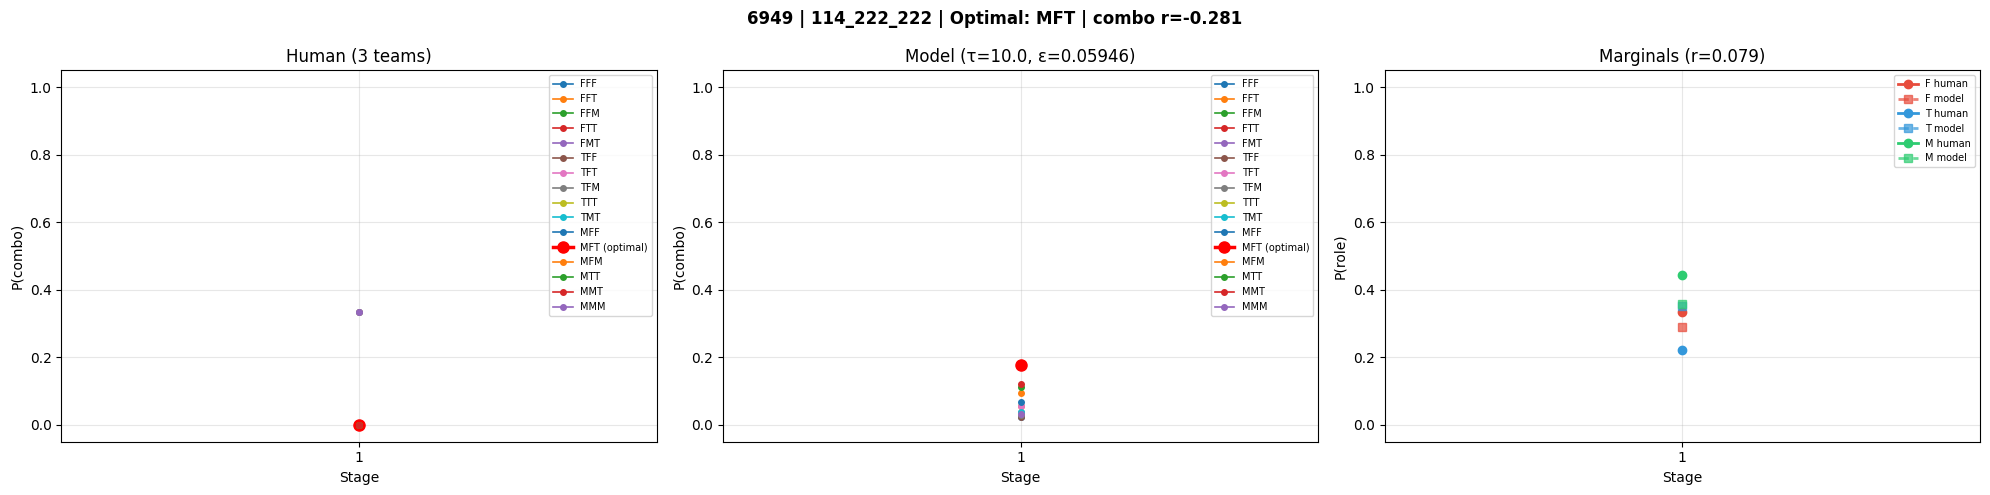

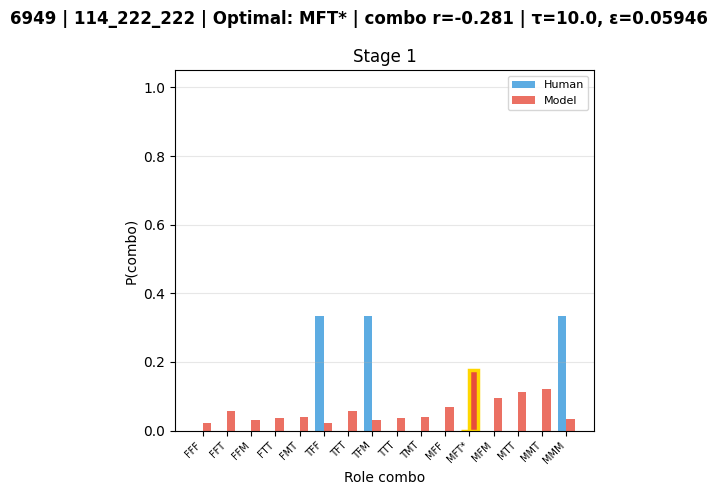

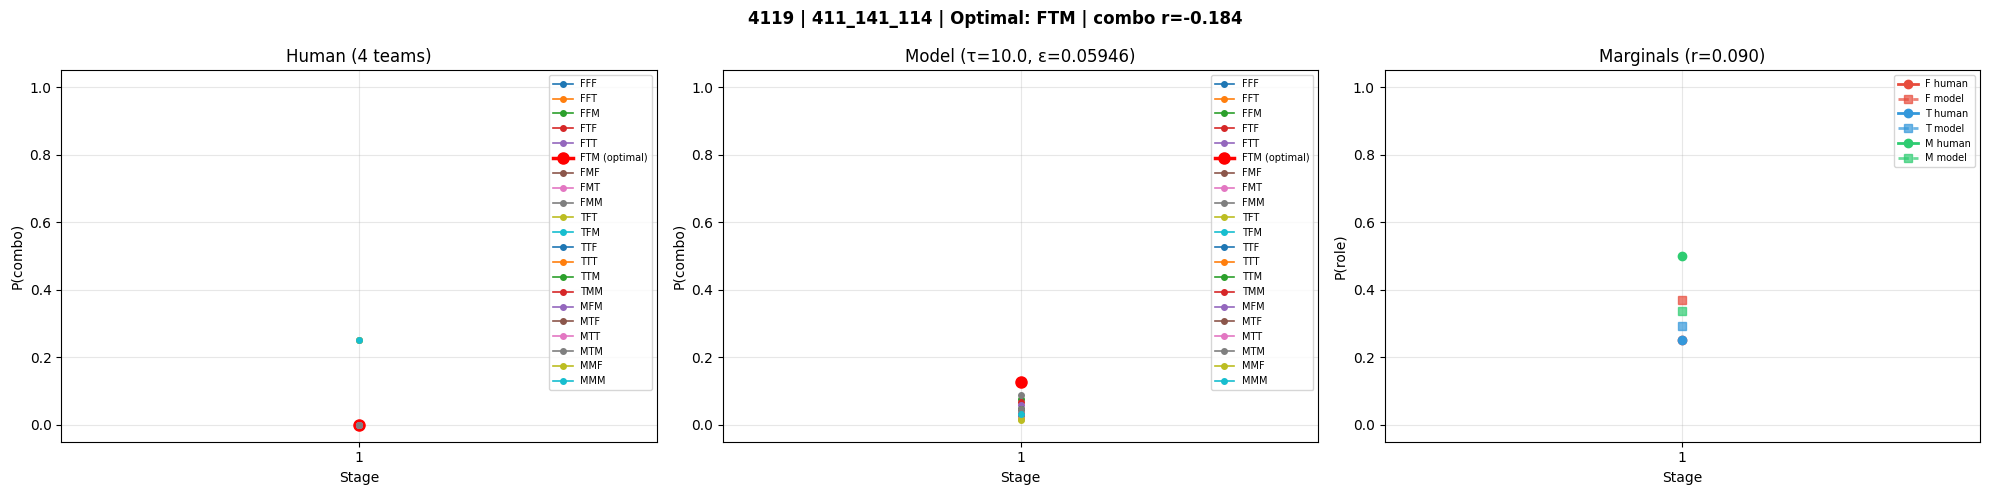

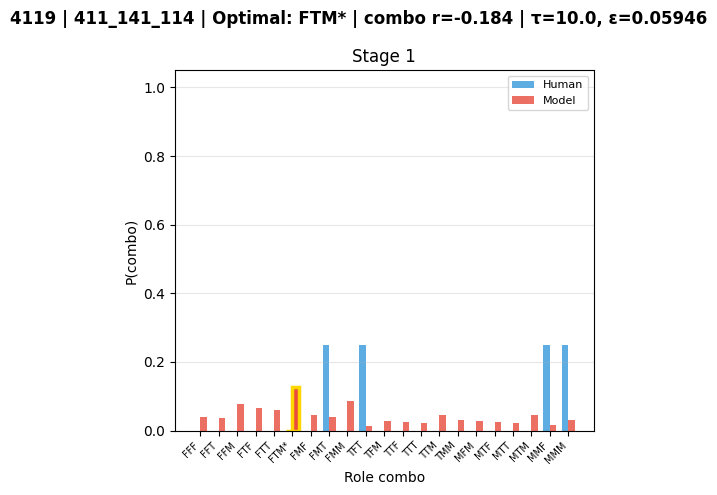

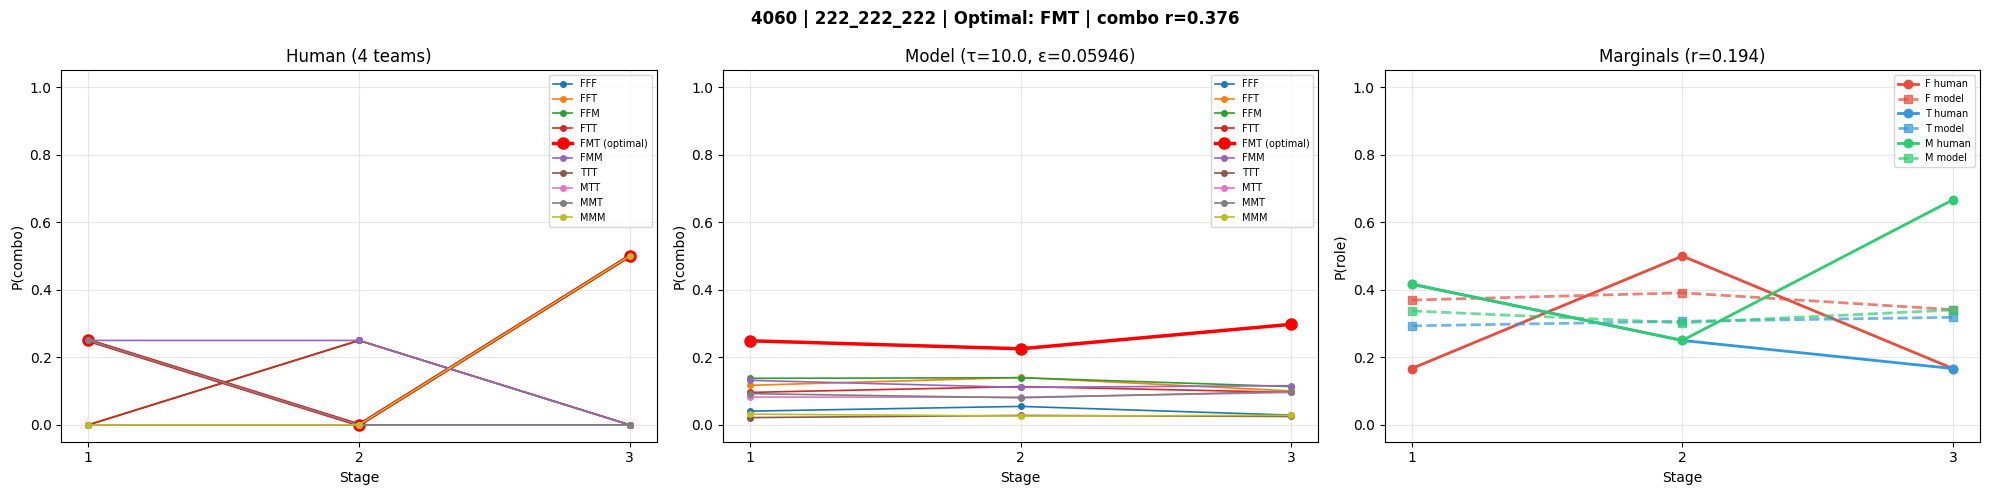

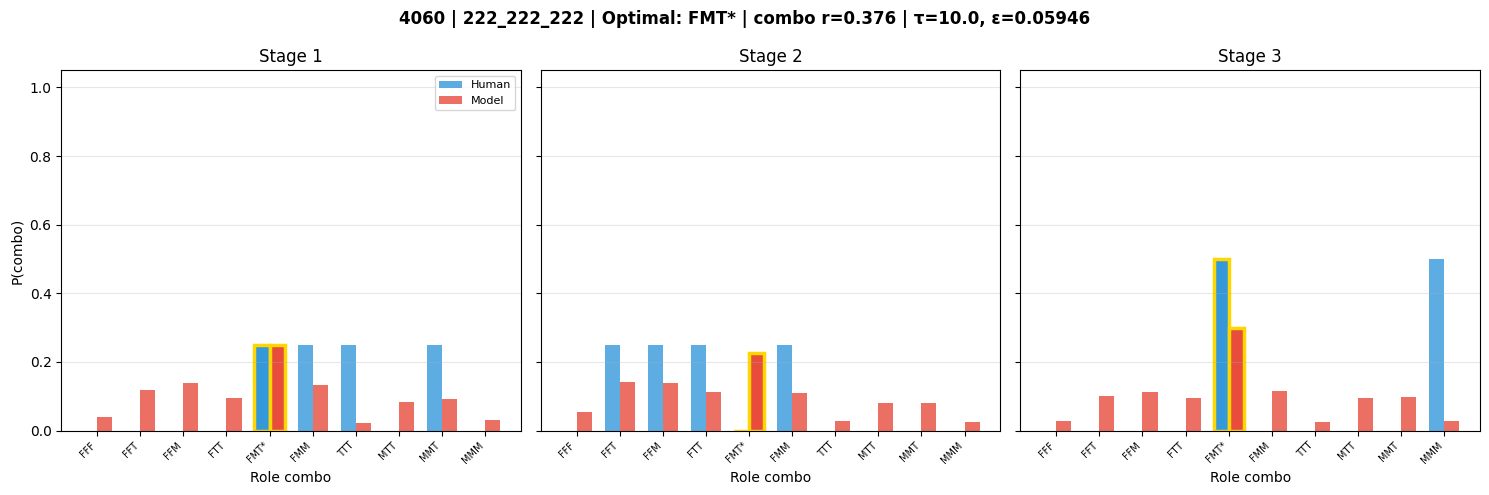

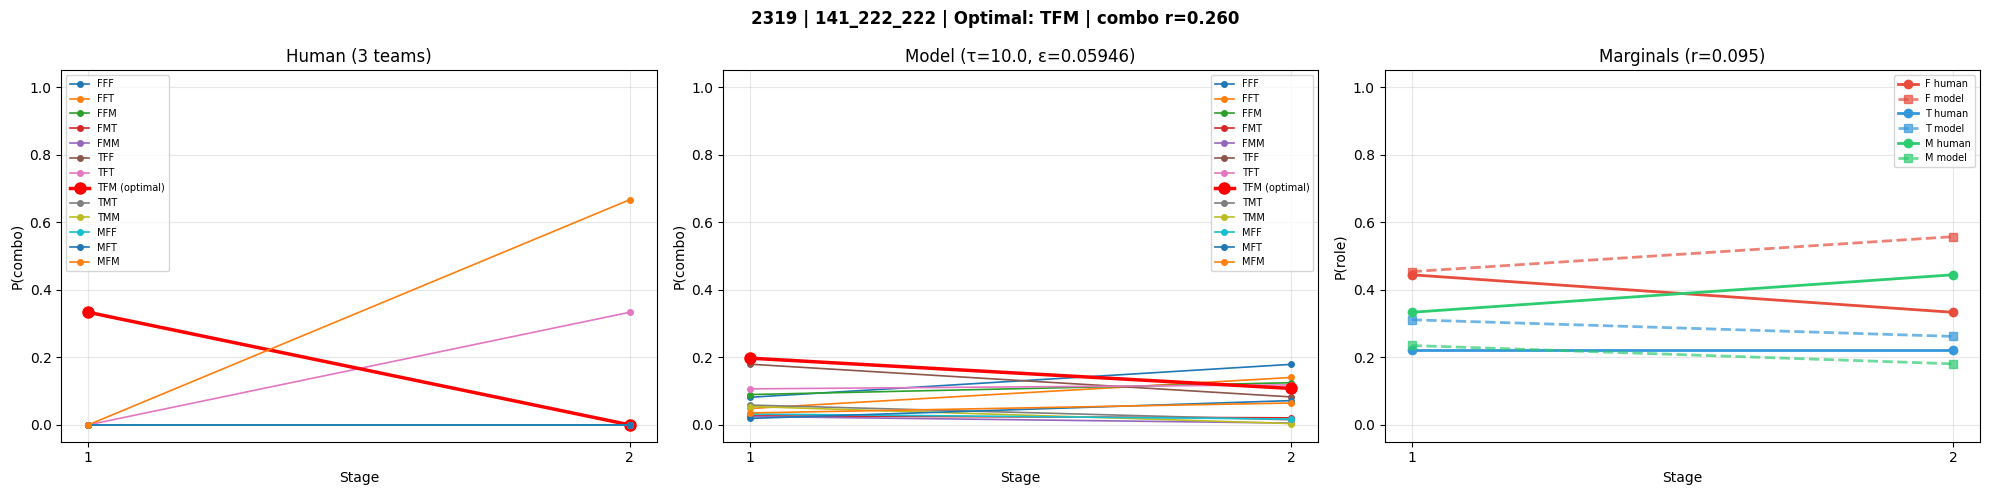

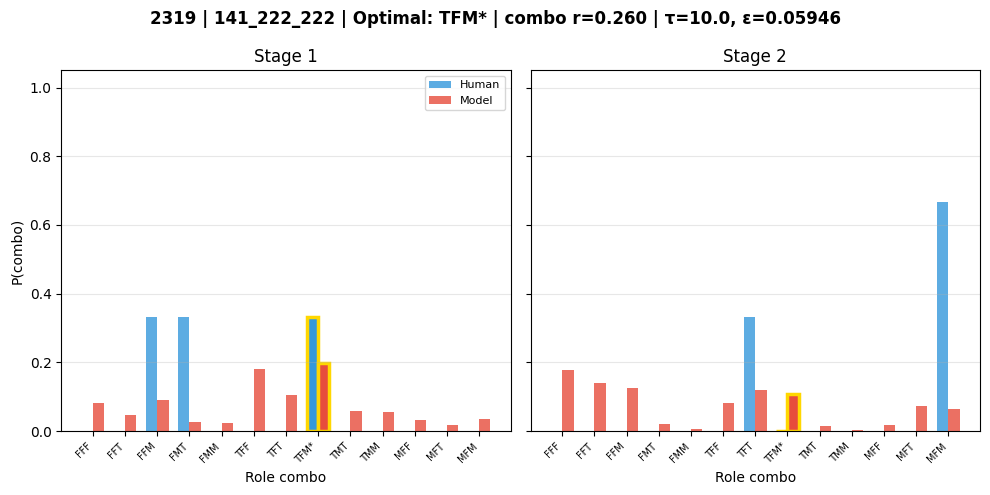

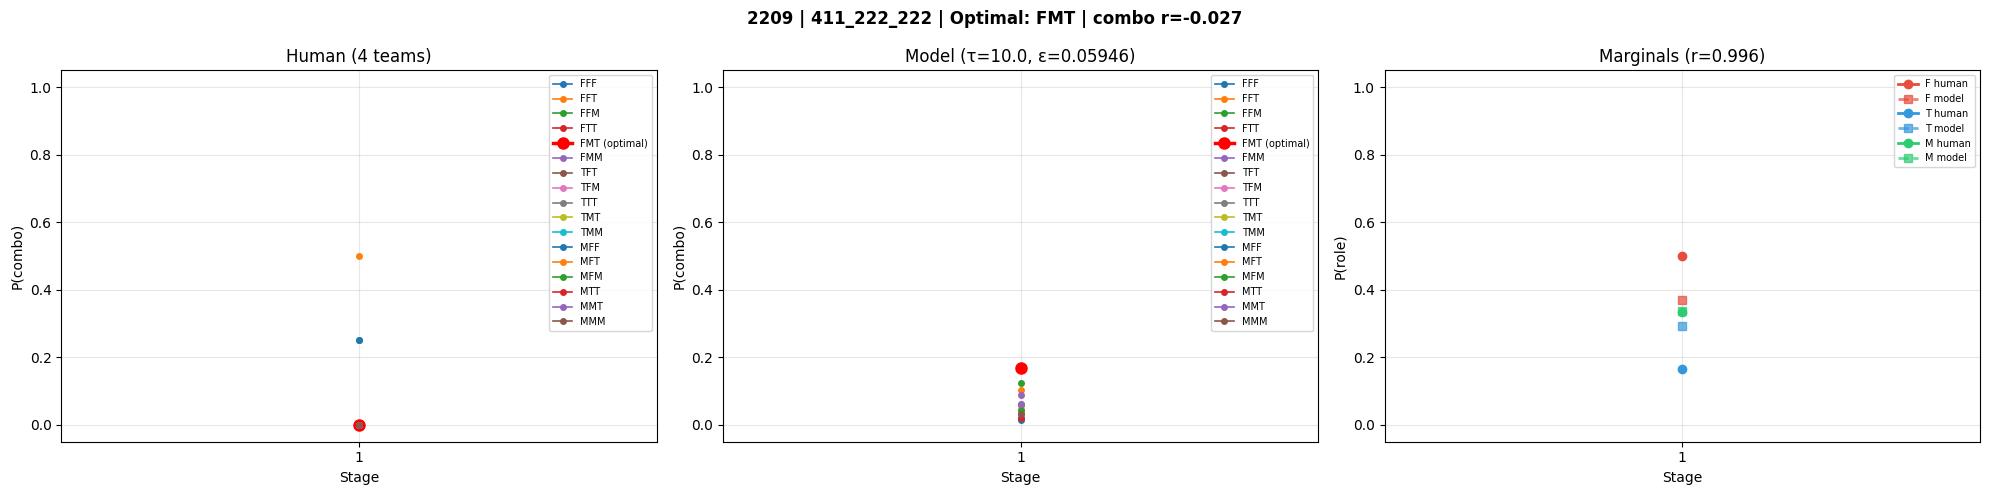

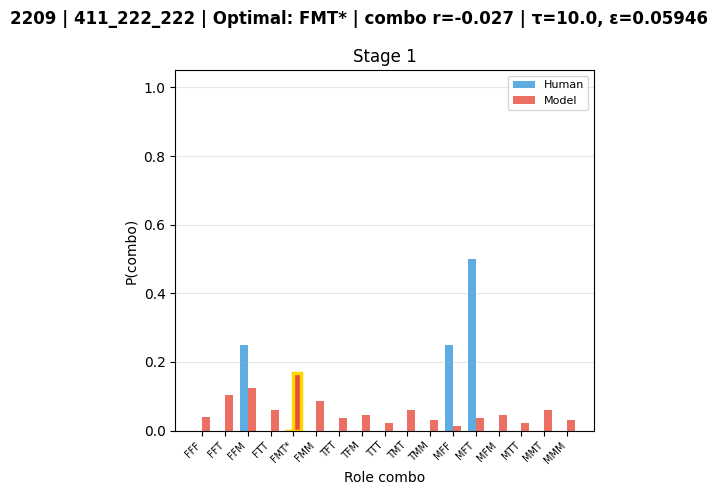

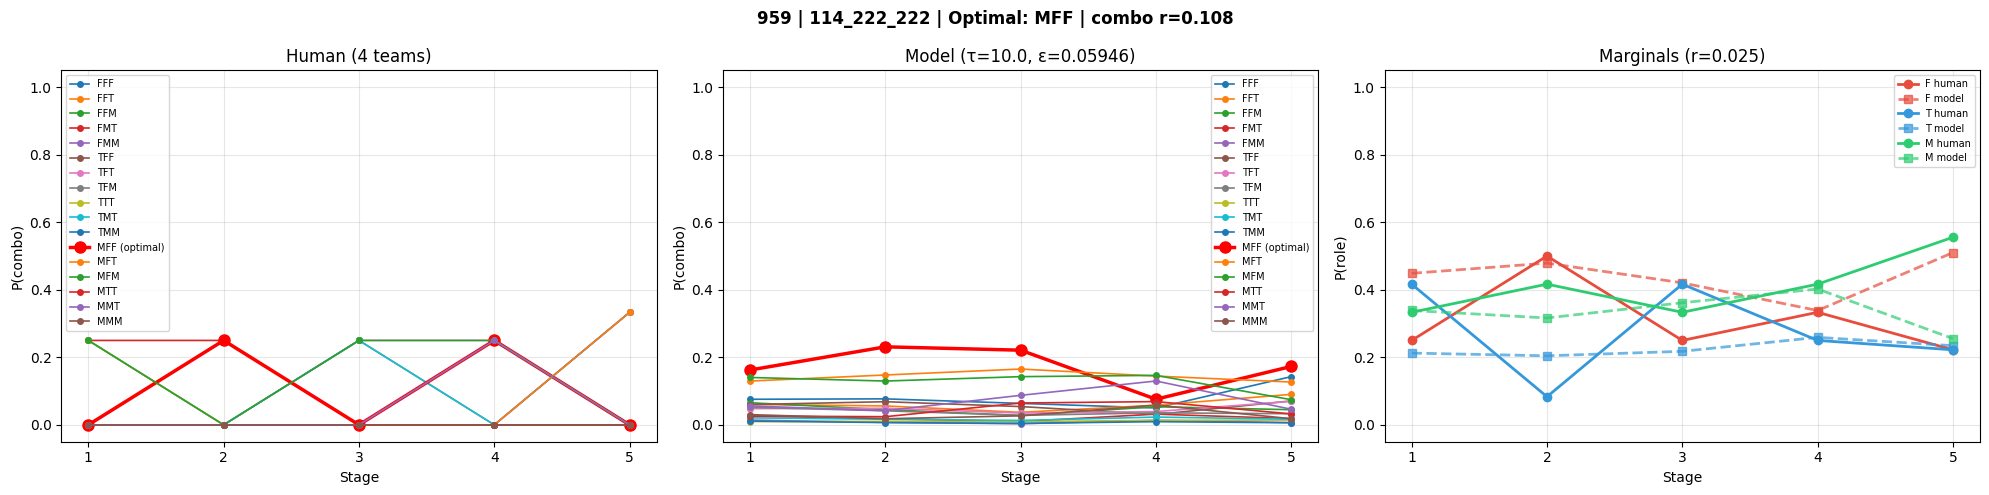

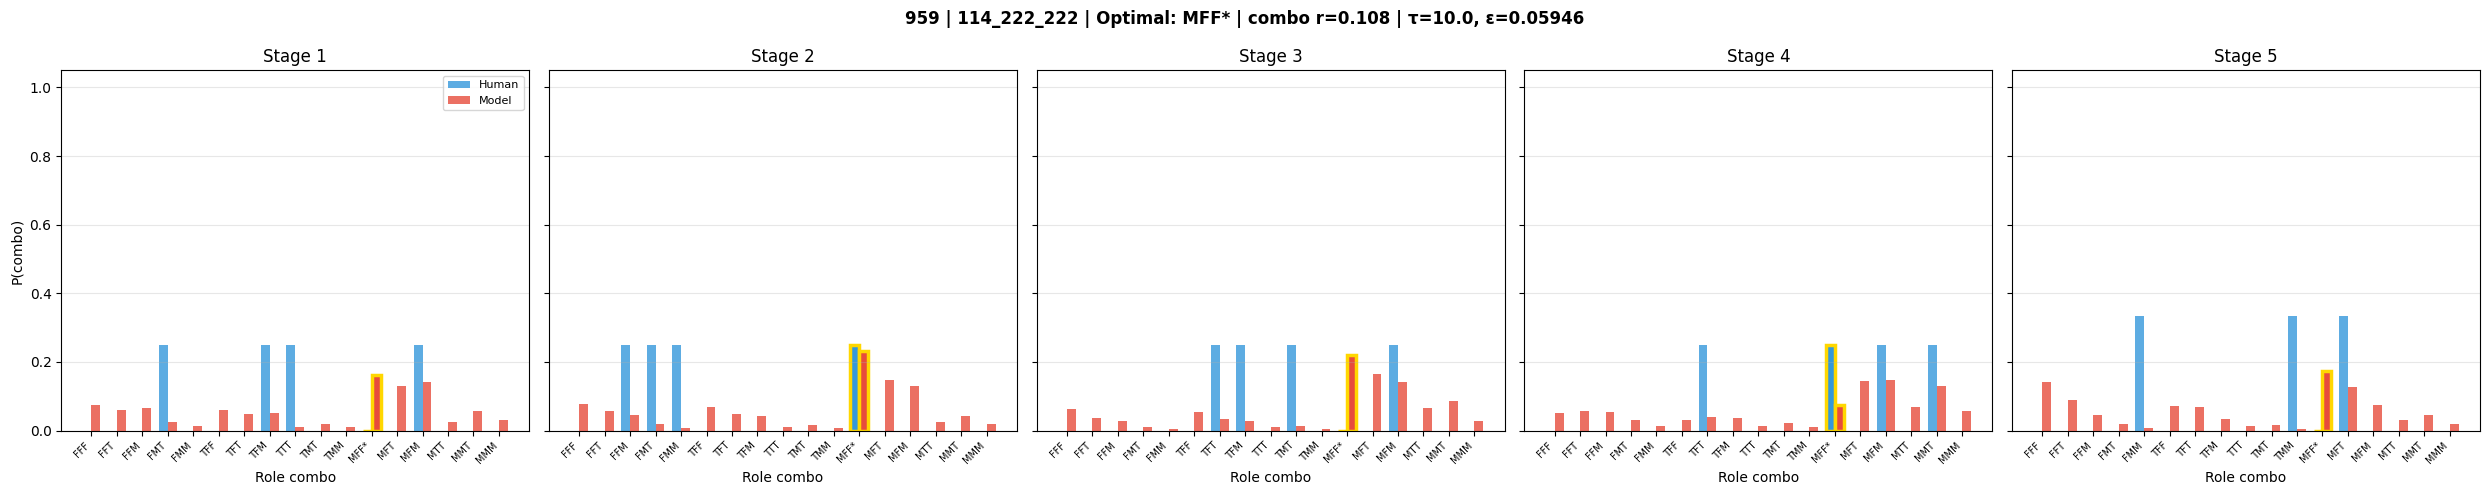

Figures saved to /Users/bhavyesh/Desktop/bayesian-role-specialization/computational_model/analysis/figures/model_comparison_online_old_pilot


In [16]:
best_predictions = run_all_predictions(
    records, tau=best_result["tau"], prior_type=prior_type, epsilon=best_result["epsilon"]
)
best_correlations = compute_pearson(best_predictions)
plot_comparison(best_predictions, best_correlations, tau=best_result["tau"], epsilon=best_result["epsilon"], save=True)
print("Figures saved to", OUTPUT_DIR)

## 5. Save Results

In [17]:
output = {
    "prior_type": prior_type,
    "best_tau": best_result["tau"],
    "best_epsilon": best_result["epsilon"],
    "best_combo_r": best_result["combo_r"],
    "best_marg_r": best_result["marg_r"],
    "best_mean_ll": best_result["mean_ll"],
    "metric_optimized": metric,
    "sweep": [
        {"tau": r["tau"], "epsilon": r["epsilon"],
         "combo_r": r["combo_r"], "marg_r": r["marg_r"], "mean_ll": r["mean_ll"]}
        for r in sorted(sweep_results, key=lambda r: (r["tau"], r["epsilon"]))
    ],
    "best_correlations": best_result["correlations"],
    "best_log_likelihood": best_result["log_likelihood"],
}

out_path = SCRIPT_DIR / "finetune_tau_results.json"
with open(out_path, "w") as f:
    json.dump(output, f, indent=2)
print(f"Results saved to {out_path}")

Results saved to /Users/bhavyesh/Desktop/bayesian-role-specialization/computational_model/analysis/finetune_tau_results.json
